In [42]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import geopandas as gpd
import folium
from folium.features import DivIcon
import branca.colormap as cm
from branca.element import MacroElement
from jinja2 import Template

In [43]:
# 14 LAD names for the Lancashire geography (12 districts + 2 unitaries)
LAD_NAMES_LANCASHIRE = {
    "Burnley","Chorley","Fylde","Hyndburn","Lancaster","Pendle","Preston",
    "Ribble Valley","Rossendale","South Ribble","West Lancashire","Wyre",
    "Blackpool","Blackburn with Darwen"
}

In [44]:
# ==================================================
# INTERACTIVE MAPS ZOOMED MAPS ZOOMED MAPS 
# ==================================================

In [45]:
# =========================
# 1. PATHS & COLUMN NAMES
# =========================

csv_path = "/Users/shrankhlagarg/Desktop/Michaelmas/CVP/Transport_Poverty_Lancashire/Data/Master_LSOA_with_TPI.csv"            # your TPI CSV
shp_path = "/Users/shrankhlagarg/Desktop/Michaelmas/CVP/Transport_Poverty_Lancashire/Data/TransportSupply/LSOA_Boundaries/Lower_layer_Super_Output_Areas/LSOA_2011_EW_BFC_V3.shp"  # your 2011 LSOA shapefile

COL_LSOA_CSV = "LSOA_Code"               # LSOA column in your CSV
COL_TPI      = "TransportPovertyIndex"   # TPI column in your CSV
LA_COL = "LADNM"

In [47]:
# ====== LOAD & MERGE ======
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()
df = df.rename(columns={COL_LSOA_CSV: "LSOA11CD"})

gdf = gpd.read_file(shp_path)
gdf.columns = gdf.columns.str.strip()

merged = gdf.merge(df, on="LSOA11CD", how="inner")
merged_wgs84 = merged.to_crs(epsg=4326)

print("Columns:", merged_wgs84.columns.tolist())

# ====== MAP SETUP ======
centre_lat = merged_wgs84.geometry.centroid.y.mean()
centre_lon = merged_wgs84.geometry.centroid.x.mean()

m = folium.Map(tiles="cartodbpositron")  # no centre/zoom here

# Fit to Lancashire bounds
minx, miny, maxx, maxy = merged_wgs84.total_bounds
m.fit_bounds([[miny, minx], [maxy, maxx]])

# Colour map
tpi_min = float(merged_wgs84[COL_TPI].min())
tpi_max = float(merged_wgs84[COL_TPI].max())


# ---- Colour map for polygons ----
tpi_min = float(merged_wgs84[COL_TPI].min())
tpi_max = float(merged_wgs84[COL_TPI].max())
cmap = cm.linear.YlOrRd_09.scale(tpi_min, tpi_max)

# ---- Big custom legend in bottom-left ----
legend = MacroElement()
legend._template = Template("""
{% macro html(this, kwargs) %}
<div style="
    position: fixed;
    bottom: 20px;
    left: 20px;
    width: 280px;
    height: 80px;
    z-index:9999;
    font-size:14px;
    background-color: rgba(255,255,255,0.95);
    border: 2px solid #555;
    padding: 8px 10px;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.3);
">
    <div style="font-weight:bold; margin-bottom:6px;">
        Transport Poverty Index (0–1)
    </div>
    <div style="
        height: 16px;
        background: linear-gradient(to right, {{ this.colors[0] }}, {{ this.colors[1] }}, {{ this.colors[2] }});
        margin-bottom: 6px;
        border: 1px solid #555;
    "></div>
    <div style="display:flex; justify-content:space-between;">
        <span>{{ this.vmin }}</span>
        <span>{{ this.vmid }}</span>
        <span>{{ this.vmax }}</span>
    </div>
</div>
{% endmacro %}
""")

legend.colors = [cmap(x) for x in [0, 0.5, 1]]
legend.vmin = f"{tpi_min:.2f}"
legend.vmid = f"{(tpi_min + tpi_max) / 2:.2f}"
legend.vmax = f"{tpi_max:.2f}"

m.add_child(legend)

def style_function(feature):
    val = feature["properties"].get(COL_TPI, None)
    if val is None:
        fill = "#ffffff"
        fill_opacity = 0.1
    else:
        fill = cmap(val)
        fill_opacity = 0.8

    return {
        "fillColor": fill,
        "color": "white",     # LSOA borders (thin)
        "weight": 0.2,
        "fillOpacity": fill_opacity,
    }

def highlight_function(feature):
    return {
        "weight": 2,
        "color": "black",
        "fillOpacity": 0.9
    }

# --- 1) LSOA polygons + tooltip (HEATMAP + HOVER) ---
gjson = folium.GeoJson(
    merged_wgs84,
    name="LSOA Transport Poverty",
    style_function=style_function,
    highlight_function=highlight_function
).add_to(m)

tooltip = GeoJsonTooltip(
    fields=["LSOA11CD", "LSOA11NM", LA_COL, COL_TPI],
    aliases=["LSOA code:", "LSOA name:", "Local authority:", "Transport Poverty Index:"],
    localize=True,
    sticky=True
)
tooltip.add_to(gjson)

# --- 2) Top 10 hotspots (BLACK DOTS) ---
top10 = merged_wgs84.nlargest(10, COL_TPI).copy()
top10 = top10.sort_values(COL_TPI, ascending=False).reset_index(drop=True)
top10["Rank"] = top10.index + 1

for _, row in top10.iterrows():
    centroid = row.geometry.centroid
    lat = centroid.y
    lon = centroid.x

    lsoa_code = row.get("LSOA11CD", "")
    lsoa_name = row.get("LSOA11NM", "")
    la_name   = row.get(LA_COL, "")
    tpi_val   = row[COL_TPI]
    rank      = int(row["Rank"])

    # Popup (on click)
    popup_html = (
        f"<b>Rank {rank} hotspot</b><br>"
        f"<b>LSOA:</b> {lsoa_code} ({lsoa_name})<br>"
        f"<b>Local authority:</b> {la_name}<br>"
        f"<b>TPI:</b> {tpi_val:.3f}"
    )

    # Hover label: LARGE, BOLD, HIGH VISIBILITY
    hover_label = f"""
        <div style="
            font-size: 18px;
            font-weight: 800;
            color: #000000;
            background-color: rgba(255,255,255,0.85);
            padding: 4px 8px;
            border-radius: 6px;
            border: 2px solid black;
        ">
            🔥 Rank {rank}: {la_name}<br>{lsoa_name}
        </div>
    """

    folium.CircleMarker(
        location=[lat, lon],
        radius=7,
        color="black",
        fill=True,
        fill_color="black",
        fill_opacity=1,
        popup=folium.Popup(popup_html, max_width=300),
        tooltip=hover_label   # <-- BIG BEAUTIFUL LABEL
    ).add_to(m)

# --- 3) LA borders as LINES (so they don't block hover) ---
la_filtered = merged_wgs84[merged_wgs84[LA_COL].isin(LAD_NAMES_LANCASHIRE)].copy()
la_boundaries = la_filtered.dissolve(by=LA_COL).reset_index()

# Convert polygons to boundary lines
la_lines = la_boundaries.copy()
la_lines.set_geometry(la_lines.boundary, inplace=True)

def la_line_style(feature):
    return {
        "color": "black",
        "weight": 2,
        "fillOpacity": 0  # irrelevant for lines
    }

folium.GeoJson(
    la_lines,
    name="Local Authority Borders",
    style_function=la_line_style
).add_to(m)

# --- 4) Big LA labels ---
for _, row in la_boundaries.iterrows():
    geom = row.geometry
    centroid = geom.centroid
    lat = centroid.y
    lon = centroid.x
    la_name = row[LA_COL]

    folium.map.Marker(
        [lat, lon],
        icon=DivIcon(
            icon_size=(160, 40),
            icon_anchor=(80, 20),
            html=f"""
                <div style="
                    font-size: 16pt;
                    font-weight: bold;
                    color: #222222;
                    text-shadow: 1px 1px 2px #ffffff;
                    white-space: nowrap;
                ">
                    {la_name}
                </div>
            """
        )
    ).add_to(m)

folium.LayerControl().add_to(m)

m.save("Transport_Poverty_Lancashire_Interactive_FINAL.html")
print("Saved: Transport_Poverty_Lancashire_Interactive_FINAL.html")

Columns: ['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng', 'GlobalID', 'geometry', 'LSOA Name_x', 'Health and Disability Decile', 'Barriers to Housing & Services Decile', 'IDAOPI Decile', 'LA_Name_x', 'HealthDisability_norm', 'HousingServices_norm', 'IDAOPI_norm', 'DeprivationCombined_norm', 'Service_users_LSOA', 'GP_PT_walk_mins', 'GP_PT_15mins_perc', 'LA_Code_x', 'Total_Above_65', 'Total_Population', '%_Above_65', 'Household deprivation (6 categories) Code', 'Household deprivation (6 categories)', 'Total_Deprived', 'Num_Households', '%_deprived', '%_Disablities', 'Car or van availability (5 categories) Code', 'Car or van availability (5 categories)', 'Total_NoVehicle', 'Total_Households', '%_with__No_car', 'LSOA Name_y', 'LADNM', 'stops_count', 'avg_departures_per_hour', 'median_departures_per_hour', 'pct_stops_lt1_per_hour', 'BusFreqBand', 'BusFreq_norm', 'BusFreqScore', 'LA_Name_y', 'LA_Code_y', 'Pop75_norm', 'Disabled_norm', 'NoCar_norm', 'IMD_norm', 'HospTr

/var/folders/d8/hkx8jz3s4_zbp6_5ff82k80h0000gn/T/ipykernel_70398/941614358.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centre_lat = merged_wgs84.geometry.centroid.y.mean()
/var/folders/d8/hkx8jz3s4_zbp6_5ff82k80h0000gn/T/ipykernel_70398/941614358.py:16: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centre_lon = merged_wgs84.geometry.centroid.x.mean()


Saved: Transport_Poverty_Lancashire_Interactive_FINAL.html


In [ ]:
### HEATMAP


Saved static PNG map to: TPI_Lancashire_Static_Map.png


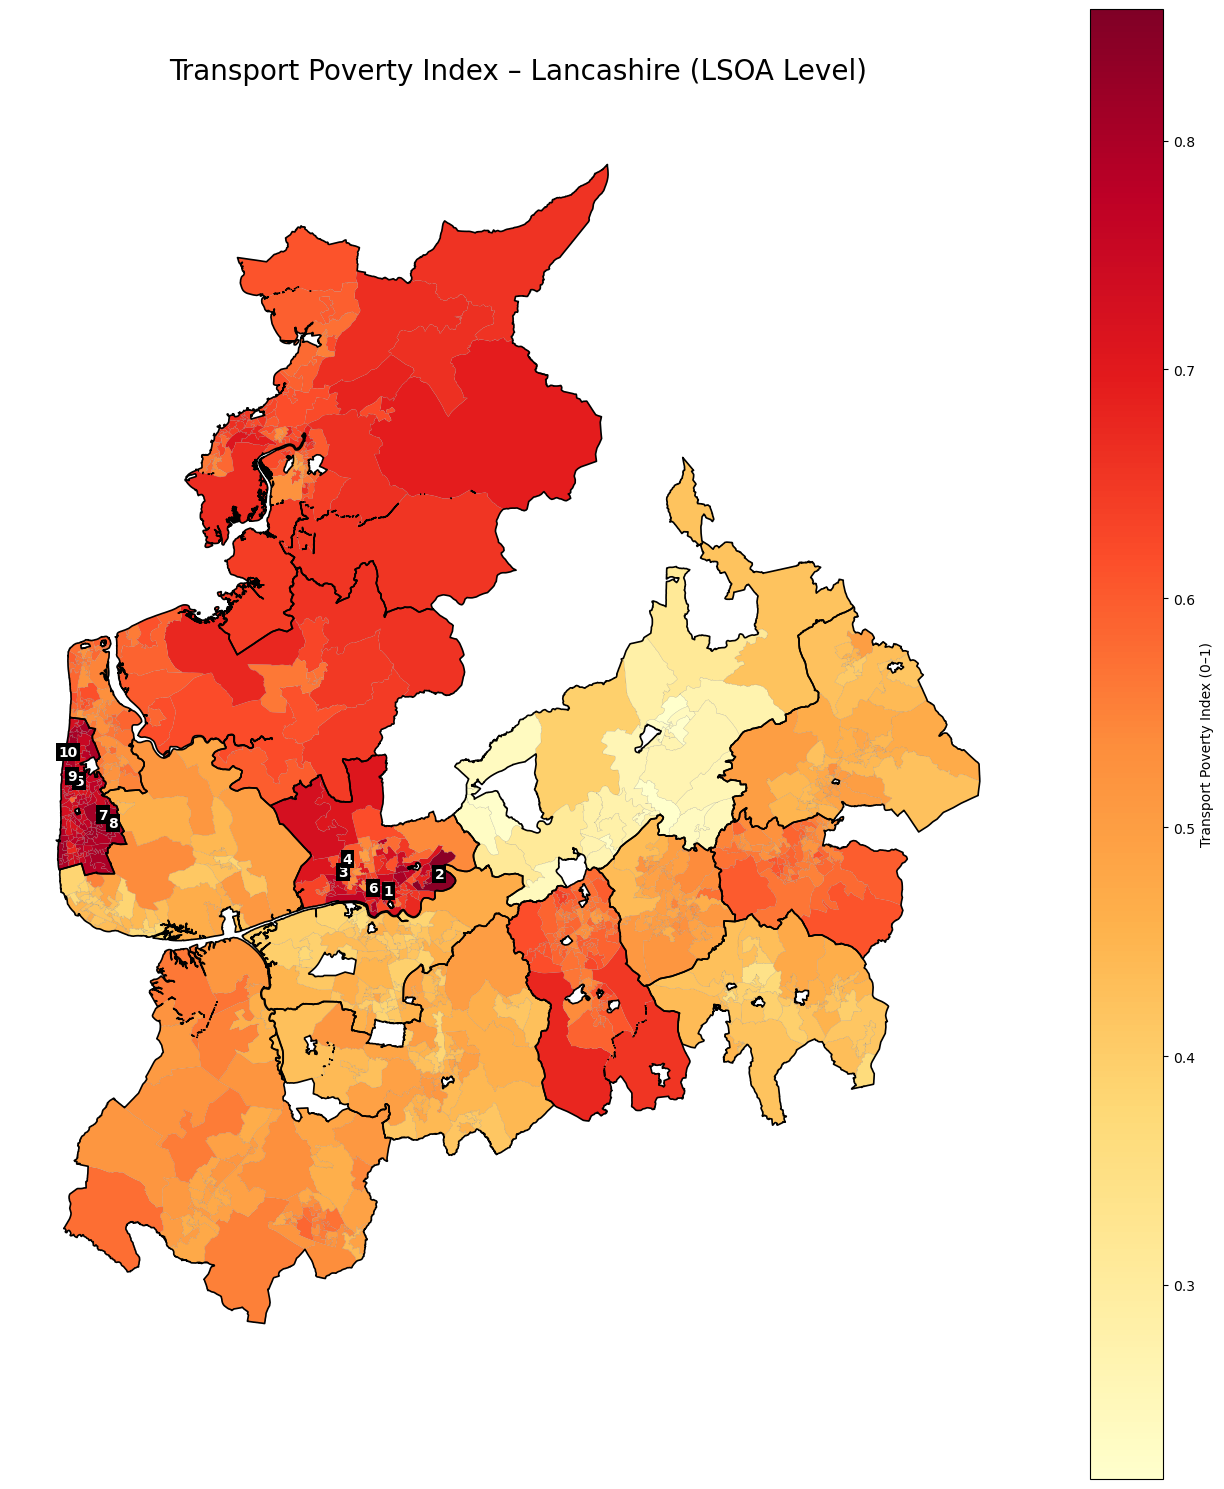

In [39]:
# Load CSV
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

# Make sure we have an LSOA ID in the CSV
if "LSOA11CD" in df.columns:
    pass  # already good
elif "LSOA_Code" in df.columns:
    df = df.rename(columns={"LSOA_Code": "LSOA11CD"})
elif "LSOA Code" in df.columns:
    df = df.rename(columns={"LSOA Code": "LSOA11CD"})
else:
    raise ValueError(f"No LSOA code column found in CSV. Columns are: {df.columns.tolist()}")

# Load shapefile
gdf = gpd.read_file(shp_path)
gdf.columns = gdf.columns.str.strip()

if "LSOA11CD" not in gdf.columns:
    raise ValueError(f"'LSOA11CD' not found in shapefile. Columns are: {gdf.columns.tolist()}")

# ============================================================
# 2. MERGE + REPROJECT
# ============================================================

merged = gdf.merge(df, on="LSOA11CD", how="inner")

# Reproject to British National Grid for nicer static plotting
merged_bng = merged.to_crs(epsg=27700)

# Local authority name column
if "LADNM" not in merged_bng.columns:
    raise ValueError(f"'LADNM' (LA name) not found. Columns: {merged_bng.columns.tolist()}")

# ============================================================
# 3. LA BORDERS + TOP 10 HOTSPOTS
# ============================================================

# LA borders
la_boundaries = merged_bng.dissolve(by="LADNM")

# Top 10 by TPI
if "TransportPovertyIndex" not in merged_bng.columns:
    raise ValueError("Column 'TransportPovertyIndex' not found in merged data.")

top10 = merged_bng.nlargest(10, "TransportPovertyIndex").copy()
top10 = top10.sort_values("TransportPovertyIndex", ascending=False)
top10["Rank"] = range(1, 11)

# ============================================================
# 4. PLOT STATIC MAP
# ============================================================

fig, ax = plt.subplots(figsize=(13, 15))

# ---- Heatmap ----
merged_bng.plot(
    column="TransportPovertyIndex",
    cmap="YlOrRd",
    linewidth=0.1,
    edgecolor="grey",
    legend=True,
    legend_kwds={
        "label": "Transport Poverty Index (0–1)",
        "orientation": "vertical"
    },
    ax=ax
)

# ---- LA Borders ----
la_boundaries.boundary.plot(
    ax=ax,
    color="black",
    linewidth=1.2,
    label="Local Authority Borders"
)

# ---- Top 10 Hotspot markers ----
top10_centroids = top10.geometry.centroid

top10_centroids.plot(
    ax=ax,
    color="black",
    markersize=45,
    label="Top 10 Hotspots"
)

# ---- Label each hotspot with its rank ----
for _, row in top10.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    rank = row["Rank"]
    plt.text(
        cx, cy,
        f"{rank}",
        fontsize=10,
        fontweight="bold",
        ha="center",
        va="center",
        color="white",
        bbox=dict(facecolor="black", edgecolor="none", pad=1.5)
    )

# ---- Title ----
ax.set_title(
    "Transport Poverty Index – Lancashire (LSOA Level)",
    fontsize=20,
    pad=20
)

ax.set_axis_off()
plt.tight_layout()

# ============================================================
# 5. SAVE PNG
# ============================================================

output_path = "TPI_Lancashire_Static_Map.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

print(f"\nSaved static PNG map to: {output_path}")